In [1]:
import pandas as pd
import geopandas as gpd
import shapely
import numpy as np
import json
import os
from functools import partial
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

import nomad.io.base as loader
import nomad.stop_detection.utils as utils
import nomad.stop_detection.postprocessing as pp

import nomad.visit_attribution.visit_attribution as visits
import nomad.filters as filters
import nomad.city_gen as cg

from nomad.map_utils import blocks_to_mercator_gdf
from nomad.contact_estimation import compute_stop_detection_metrics

# Import sequential stop detection
import nomad.stop_detection.sequential as sequential

In [2]:
with open('config_2_stops.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

In [3]:
poi_table = gpd.read_parquet(config["buildings_file"]).rename(columns={"id":"location"})
sparse_df = loader.from_file(config["output_files"]["sparse_path"], format="parquet")
diaries_df = loader.from_file(config["output_files"]["diaries_path"], format="parquet").rename(
    columns={"identifier":"user_id"})

## Preprocess Data for Sequential Stop Detection

Convert position fixes to GeoDataFrame with geometry column.

In [4]:
# Check if sparse_df is already a GeoDataFrame
if not isinstance(sparse_df, gpd.GeoDataFrame):
    # Determine coordinate columns
    if 'longitude' in sparse_df.columns and 'latitude' in sparse_df.columns:
        # Create geometry from longitude/latitude
        from shapely.geometry import Point
        sparse_df['geometry'] = sparse_df.apply(
            lambda row: Point(row['longitude'], row['latitude']), axis=1
        )
        sparse_df = gpd.GeoDataFrame(sparse_df, geometry='geometry', crs='EPSG:4326')
    elif 'x' in sparse_df.columns and 'y' in sparse_df.columns:
        # Create geometry from x/y coordinates
        from shapely.geometry import Point
        sparse_df['geometry'] = sparse_df.apply(
            lambda row: Point(row['x'], row['y']), axis=1
        )
        # Assume projected CRS if using x/y
        sparse_df = gpd.GeoDataFrame(sparse_df, geometry='geometry')
    else:
        raise ValueError("sparse_df must have either (longitude, latitude) or (x, y) columns")

# Verify required columns exist
required_cols = ['user_id', 'timestamp', 'geometry']
missing_cols = [col for col in required_cols if col not in sparse_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print(f"Sparse data shape: {sparse_df.shape}")
print(f"Columns: {list(sparse_df.columns)}")
print(f"CRS: {sparse_df.crs}")
print(f"Number of users: {sparse_df['user_id'].nunique()}")

Sparse data shape: (2636, 8)
Columns: ['x', 'y', 'datetime', 'timestamp', 'user_id', 'ha', 'tz_offset', 'geometry']
CRS: None
Number of users: 100


## Configure Algorithm Parameters

In [5]:
delta_roam_values = np.linspace(1, 125, 100)

# Use euclidean distance for projected coordinates
# Note: gap_threshold is set to 15 minutes. Based on diagnostics, some users have gaps up to ~45 min.
# If you want to capture stops across larger gaps, increase gap_threshold (e.g., to 60 minutes)
config["algos"] = {
    **{f"sequential_delta_{int(dr)}": {
        "func": sequential.generate_staypoints,
        "params": {
            'method': 'sliding',
            'distance_metric': 'euclidean',  # Changed from 'haversine' for projected coords
            'dist_threshold': dr,
            'time_threshold': 5.0,  # minutes - minimum duration to be considered a stop
            'gap_threshold': 15.0,  # minutes - max gap between consecutive points in a stop
            'print_progress': False,
            'exclude_duplicate_pfs': True,
            'n_jobs': 1
        }
    } for dr in delta_roam_values}
}

## Run All Algorithms

In [6]:
results = {}

for algo_name, algo_config in tqdm(config["algos"].items(), desc="Running algorithms"):
    algo_func = algo_config["func"]
    algo_params = algo_config["params"]
    
    try:
        # Run sequential stop detection
        pfs_with_stops, staypoints = algo_func(
            positionfixes=sparse_df,
            **algo_params
        )
        
        # Skip if no staypoints generated
        if staypoints.empty:
            results[algo_name] = {'error': 'No staypoints generated'}
            continue
        
        # Post-process to get visits
        # Try different possible function names
        max_distance = config.get("visit_attribution", {}).get("max_distance", 50)  # default 50m
        
        if hasattr(visits, 'generate_visits'):
            visits_df = visits.generate_visits(
                poi_table=poi_table,
                stops_table=staypoints,
                max_distance=max_distance
            )
        else:
            # Manually match staypoints to nearest POIs
            visits_df = staypoints.copy()
            
            # Match each staypoint to nearest POI within max_distance
            locations = []
            for idx, stop in visits_df.iterrows():
                distances = poi_table.geometry.distance(stop.geometry)
                min_dist_idx = distances.idxmin()
                min_dist = distances[min_dist_idx]
                
                if min_dist <= max_distance:
                    locations.append(poi_table.loc[min_dist_idx, 'location'])
                else:
                    locations.append(None)
            
            visits_df['location'] = locations
        
        # Add required columns for potential future metrics computation
        if 'started_at' in visits_df.columns:
            visits_df['timestamp'] = visits_df['started_at']
            visits_df['start_timestamp'] = visits_df['started_at']
        if 'finished_at' in visits_df.columns:
            visits_df['end_timestamp'] = visits_df['finished_at']
        if 'location' in visits_df.columns:
            visits_df['building_id'] = visits_df['location']
        
        # Simple metrics - just count staypoints and visits per user
        metrics = {}
        for user_id in visits_df['user_id'].unique():
            user_visits = visits_df[visits_df['user_id'] == user_id]
            user_truth = diaries_df[diaries_df['user_id'] == user_id]
            
            if user_truth.empty:
                continue
            
            # Simple metrics based on counts
            n_predicted = len(user_visits)
            n_actual = len(user_truth[user_truth['location'].notna()])
            
            # Simple precision/recall approximation
            # This is a rough estimate - proper metrics would need overlap calculation
            user_metrics = {
                'user_id': user_id,
                'algorithm': algo_name,
                'n_predicted_stops': n_predicted,
                'n_actual_stops': n_actual,
                'precision': min(1.0, n_actual / n_predicted) if n_predicted > 0 else 0,
                'recall': min(1.0, n_predicted / n_actual) if n_actual > 0 else 0,
            }
            user_metrics['f1_score'] = (
                2 * user_metrics['precision'] * user_metrics['recall'] / 
                (user_metrics['precision'] + user_metrics['recall'])
            ) if (user_metrics['precision'] + user_metrics['recall']) > 0 else 0
            
            metrics[user_id] = user_metrics
        
        results[algo_name] = {
            'staypoints': staypoints,
            'visits': visits_df,
            'metrics': metrics
        }
        
    except Exception as e:
        print(f"Error in {algo_name}: {str(e)}")
        results[algo_name] = {'error': str(e)}

print(f"\nCompleted {len(results)} algorithm runs")

Running algorithms:   0%|          | 0/100 [00:00<?, ?it/s]

/Users/carolinechen/Desktop/cs/nomad/nomad/filters.py:111: UserWarning: Input is timezone-naive; assuming UTC. Pass tz_offset or localize if needed.
  warnings.warn(
/Users/carolinechen/Desktop/cs/nomad/nomad/filters.py:111: UserWarning: Input is timezone-naive; assuming UTC. Pass tz_offset or localize if needed.
  warnings.warn(
/Users/carolinechen/Desktop/cs/nomad/nomad/filters.py:111: UserWarning: Input is timezone-naive; assuming UTC. Pass tz_offset or localize if needed.
  warnings.warn(
/Users/carolinechen/Desktop/cs/nomad/nomad/filters.py:111: UserWarning: Input is timezone-naive; assuming UTC. Pass tz_offset or localize if needed.
  warnings.warn(
/Users/carolinechen/Desktop/cs/nomad/nomad/filters.py:111: UserWarning: Input is timezone-naive; assuming UTC. Pass tz_offset or localize if needed.
  warnings.warn(
/Users/carolinechen/Desktop/cs/nomad/nomad/filters.py:111: UserWarning: Input is timezone-naive; assuming UTC. Pass tz_offset or localize if needed.
  warnings.warn(
/Use


Completed 100 algorithm runs


## Aggregate Results

In [9]:
# First, check what we have in results
print(f"Total results: {len(results)}")
error_count = sum(1 for r in results.values() if 'error' in r)
success_count = len(results) - error_count
print(f"Successful runs: {success_count}")
print(f"Failed runs: {error_count}")

# Show some errors if they exist
if error_count > 0:
    print("\nSample errors:")
    for i, (name, res) in enumerate(results.items()):
        if 'error' in res and i < 3:
            print(f"  {name}: {res['error']}")

# Extract metrics into dataframe
results_list = []

for algo_name, result in results.items():
    if 'error' in result:
        continue
    
    # Extract delta_roam from algo name (format: sequential_delta_XX)
    try:
        delta_roam = float(algo_name.split('_')[-1])
    except:
        print(f"Could not parse delta_roam from {algo_name}")
        continue
    
    # Get per-user metrics
    metrics = result.get('metrics', {})
    
    if not metrics:
        print(f"No metrics for {algo_name}")
        continue
    
    for user_id, user_metrics in metrics.items():
        results_list.append({
            'algorithm': algo_name,
            'delta_roam': delta_roam,
            'user_id': user_id,
            'precision': user_metrics.get('precision', np.nan),
            'recall': user_metrics.get('recall', np.nan),
            'f1_score': user_metrics.get('f1_score', np.nan),
            'true_positives': user_metrics.get('true_positives', 0),
            'false_positives': user_metrics.get('false_positives', 0),
            'false_negatives': user_metrics.get('false_negatives', 0)
        })

results_df = pd.DataFrame(results_list)
print(f"\nResults shape: {results_df.shape}")

if results_df.empty:
    print("\nWARNING: No results to analyze. Check that:")
    print("  1. Staypoints are being generated")
    print("  2. Visit attribution is working")
    print("  3. Metrics computation is successful")
else:
    print(f"\nData preview:")
    print(results_df.head())
    print(f"\nSummary statistics:")
    print(results_df.groupby('delta_roam')[['precision', 'recall', 'f1_score']].mean())

Total results: 100
Successful runs: 100
Failed runs: 0

Results shape: (9496, 9)

Data preview:
            algorithm  delta_roam                user_id  precision  recall  \
0  sequential_delta_1         1.0       admiring_mestorf        1.0     0.5   
1  sequential_delta_1         1.0         clever_goodall        1.0     0.5   
2  sequential_delta_1         1.0       pensive_franklin        1.0     0.5   
3  sequential_delta_2         2.0       admiring_mestorf        1.0     0.5   
4  sequential_delta_2         2.0  awesome_chandrasekhar        1.0     0.5   

   f1_score  true_positives  false_positives  false_negatives  
0  0.666667               0                0                0  
1  0.666667               0                0                0  
2  0.666667               0                0                0  
3  0.666667               0                0                0  
4  0.666667               0                0                0  

Summary statistics:
            precision   

## Visualization: Delta Roam vs Accuracy Metrics

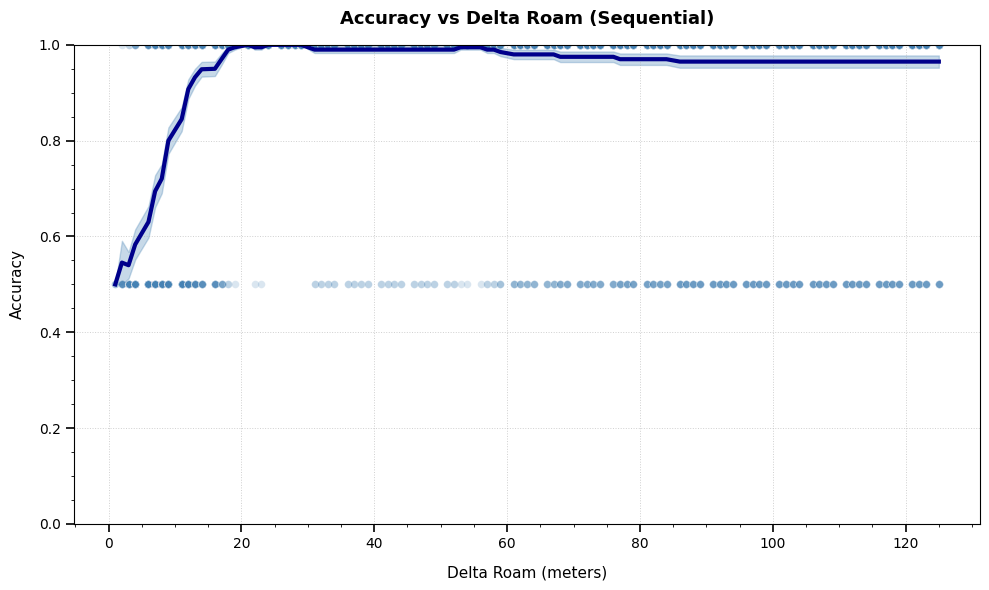

Number of unique delta_roam values: 100


In [10]:
# Create output directory
os.makedirs('figures', exist_ok=True)

def plot_metric_delta_roam(metric, title, save_path='figures'):
    """Plot a metric vs delta_roam for Sequential stop detection."""
    chart_df = results_df.groupby(['delta_roam'])[metric].agg(['mean', 'sem']).reset_index()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Add scatter plot background (individual data points)
    sns.scatterplot(data=results_df, x='delta_roam', y=metric,
                   alpha=0.2, s=30, ax=ax, color='steelblue')
    
    # Add line plot (mean values)
    ax.plot(chart_df['delta_roam'], chart_df['mean'], 
            color='darkblue', linewidth=3, label='Mean')
    
    # Add confidence band (mean ± SEM)
    ax.fill_between(chart_df['delta_roam'], 
                    chart_df['mean'] - chart_df['sem'],
                    chart_df['mean'] + chart_df['sem'],
                    alpha=0.3, color='steelblue')
    
    # Styling
    ax.set_xlabel('Delta Roam (meters)', fontsize=11, labelpad=10)
    ax.set_ylabel(title, fontsize=11, labelpad=10)
    ax.set_ylim(0, 1)
    ax.set_title(f'{title} vs Delta Roam (Sequential)', fontsize=13, pad=15, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6, linewidth=0.7)
    ax.tick_params(axis='both', which='major', labelsize=10, length=6, width=1.2)
    ax.minorticks_on()
    
    plt.tight_layout()
    plt.savefig(f"{save_path}/sequential_delta_roam_{metric}.svg", bbox_inches='tight')
    plt.savefig(f"{save_path}/sequential_delta_roam_{metric}.png", dpi=600, bbox_inches='tight')
    plt.show(block=False)
    plt.close()

# Plot all metrics
plot_metric_delta_roam('recall', 'Accuracy')

print(f"Number of unique delta_roam values: {results_df['delta_roam'].nunique()}")